In [3]:
import sys
# !{sys.executable} -m pip install xlrd

In [4]:
import pandas as pd
import os
import re

import arcpy
import pandas as pd
import geopandas as gpd

import json
# import asyncio
# import httpx


In [5]:
# name
project_name = 'muna'

In [6]:
## arcgis project setup load
aprx = arcpy.mp.ArcGISProject('CURRENT')
print([m.name for m in aprx.listMaps()])

['gps', 'sra']


In [7]:
# setup map layer interaction arcpy
m = [m for m in aprx.listMaps() if m.name == 'sra'][0]

# check the list layers
print([l.name for l in m.listLayers()])

['LC_MoF_1990_2024_muna_cleaned', 'LC_MoF_1990_2024_muna_dissolved', 'LC_MoF_1990_2024_muna', 'analysis_lulc', 'PL_1990_Clipped_muna', 'PL_1990_Clipped_muna_dis', 'PL_1996_Clipped_muna', 'PL_1996_Clipped_muna_dis', 'PL_2000_Clipped_muna', 'PL_2000_Clipped_muna_dis', 'PL_2003_Clipped_muna', 'PL_2003_Clipped_muna_dis', 'PL_2006_Clipped_muna', 'PL_2006_Clipped_muna_dis', 'PL_2009_Clipped_muna', 'PL_2009_Clipped_muna_dis', 'PL_2011_Clipped_muna', 'PL_2011_Clipped_muna_dis', 'PL_2012_Clipped_muna', 'PL_2012_Clipped_muna_dis', 'PL_2013_Clipped_muna', 'PL_2013_Clipped_muna_dis', 'PL_2014_Clipped_muna', 'PL_2014_Clipped_muna_dis', 'PL_2015_Clipped_muna', 'PL_2015_Clipped_muna_dis', 'PL_2016_Clipped_muna', 'PL_2016_Clipped_muna_dis', 'PL_2020_Clipped_muna', 'PL_2020_Clipped_muna_dis', 'PL_2021_Clipped_muna', 'PL_2021_Clipped_muna_dis', 'PL_2022_Clipped_muna', 'PL_2022_Clipped_muna_dis', 'PL_2017_Clipped_muna', 'PL_2017_Clipped_muna_dis', 'PL_2018_Clipped_muna', 'PL_2018_Clipped_muna_dis', 'PL_2

In [10]:
# the original workspace location
scratch_local_folder = r'\\Mac\Home\Documents\ArcGIS\Projects\treeo_analysis\treeo_analysis.gdb'
# arcpy.env.workspace = scratch_local_folder # later do this again if needed to list the result

scratch_folder = r"\\Mac\\Home\\Documents\\ArcGIS\\Projects\\treeo_analysis\\"

#location of downloader webgis
workspace_downloader = r'\\Mac\Home\Documents\arcgis_restapi_notebooks\webgis_downloader'

In [66]:
dict_lc_fields = {
    'PL_1990': 'pl90_id',
    'PL_1996': 'pl96_id',
    'PL_2000': 'pl00_id',
    'PL_2003': 'pl03_id',
    'PL_2006': 'pl06_id',
    'PL_2009': 'pl09_id',
    'PL_2011': 'pl11_id',
    'PL_2012': 'pl12_id',
    'PL_2013': 'pl13_id',
    'PL_2014': 'pl14_id',
    'PL_2015': 'pl15_id',
    'PL_2016': 'pl16_id',
    'PL_2017': 'pl17_id',
    'PL_2018': 'PL_18_ID',
    'PL_2019': 'PL_19_R',
    'PL_2020': 'pl2020_id',
    'PL_2021': 'pl2021_id',
    'PL_2022': 'pl2022_id',
     'output_json_PL_2023_merge': 'PL2023_ID',
    'output_json_PL_2024_merge': 'PL2024_ID'
}

lc_fields = [fields for pl, fields in dict_lc_fields.items()]

desc_year ={
    'pl90_id':1990,
 'pl96_id':1996,
 'pl00_id':2000,
 'pl03_id':2003,
 'pl06_id':2006,
 'pl09_id':2009,
 'pl11_id':2011,
 'pl12_id':2012,
 'pl13_id':2013,
 'pl14_id':2014,
 'pl15_id':2015,
 'pl16_id':2016,
 'pl17_id':2017,
 'PL_18_ID':2018,
 'PL_19_R':2019,
 'pl2020_id':2020,
 'pl2021_id':2021,
 'pl2022_id':2022,
 'PL2023_ID':2023,
 'PL2024_ID':2024
} 

In [12]:
### analysis emission factor start from this cells forward
# acquire list of land use code reference
lc_code = r'C:\Users\q_bal\Documents\arcgis_restapi_notebooks\Landcover Code MoEF.csv'
lc_code_df = pd.read_csv(lc_code)
display(lc_code_df)

# pythonize object dict, list
lc_code_df_dict=lc_code_df['kode'].to_dict()
print(lc_code_df_dict)
lclist= []
for k in lc_code_df_dict.keys():
    temp = lc_code_df_dict[k]
    lclist.append(temp)
print(lclist)

,kode,keterangan,Description,Description2
0,2001,Hutan lahan kering primer,Primary Dryland Forest,Forested land
1,2002,Hutan lahan kering sekunder / bekas tebangan,Secondary Dryland Forest,Forested land
2,2005,Hutan rawa primer,Primary Swamp Forest,Forested land
3,20051,Hutan rawa sekunder / bekas tebangan,Secondary Swamp Forest,Forested land
4,2004,Hutan mangrove primer,Primary Mangrove Forest,Forested land
5,20041,Hutan mangrove sekunder / bekas tebangan,Secondary Mangrove Forest,Forested land
6,2006,Hutan tanaman,Plantation forest,NaN
7,2010,Perkebunan / Kebun,Estate crop,NaN
8,2007,Semak belukar,Dry shrub,Degraded land
9,20071,Semak belukar rawa,Wet shrub,Degraded land


{0: 2001, 1: 2002, 2: 2005, 3: 20051, 4: 2004, 5: 20041, 6: 2006, 7: 2010, 8: 2007, 9: 20071, 10: 3000, 11: 20091, 12: 20092, 13: 20093, 14: 20094, 15: 2012, 16: 20122, 17: 2014, 18: 20141, 19: 5001, 20: 50011, 21: 2500, 22: 20121}
[2001, 2002, 2005, 20051, 2004, 20041, 2006, 2010, 2007, 20071, 3000, 20091, 20092, 20093, 20094, 2012, 20122, 2014, 20141, 5001, 50011, 2500, 20121]


In [67]:
# function to convert feature class to df and later restructure to timeseries lulcc
def restructure_timeseries_lulcc(feature_class)  -> pd.DataFrame:

    # to pandas from feature class
    # feature_class = in_feature
    # feature_class = f'LC_MoF_1990_2024_{project_name}_cleaned' # hardcoded if you want to run directly  to this cell
    
    # Create a list to store the field names
    field_names = [field.name for field in arcpy.ListFields(feature_class)]
    
    # Use arcpy.da.SearchCursor to retrieve the data
    data = [row for row in arcpy.da.SearchCursor(feature_class, field_names)]
    
    # Convert the data to a Pandas DataFrame
    df = pd.DataFrame(data, columns=field_names)
     
    # df.columns
    
    # melt -> restructure data
    meltdf = pd.melt(df, id_vars=['area_ha'], value_vars=lc_fields )
    # meltdf

    Repiv = meltdf.pivot_table(values='area_ha',index=['value'],columns=['variable'],
                               aggfunc='sum', #margins=True
                              )
    # Repiv = Repiv.drop(columns="All")
    area_ha_lulcc = Repiv[lc_fields]
    # area_ha_lulcc

    lc_area_with_desc = pd.merge(area_ha_lulcc,lc_code_df[['kode','Description']], left_index=True, right_on='kode',
         how='left')
    lc_area_with_desc = lc_area_with_desc[['kode','Description'] + lc_fields]
    lc_area_with_desc.columns = ['code','description']+[year for code,year in desc_year.items()] 
    # lc_area_with_desc

    return lc_area_with_desc

In [70]:
## get the lulcc
layer_name = f'LC_MoF_1990_2024_{project_name}_cleaned'
lc_area_with_desc = restructure_timeseries_lulcc(layer_name)

In [71]:
display(lc_area_with_desc)

,code,description,1990,1996,2000,2003,2006,2009,2011,2012,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
1,2002,Secondary Dryland Forest,1247.493963,1247.493963,1138.546871,1138.546871,1138.546871,1138.546871,1138.546871,1138.546871,...,1138.546871,1138.546871,1138.546871,1138.546871,1113.482126,1113.482126,1113.482126,1113.940277,1088.153038,1088.153038
8,2007,Dry shrub,354.780253,354.780253,463.727346,463.727346,463.727346,463.727346,463.727346,463.727346,...,463.727346,463.727346,463.727346,463.727346,484.489205,484.379319,570.427139,570.427139,564.754953,564.754953
15,2012,Settlement areas,3.543062,3.543062,3.543062,3.543062,3.543062,3.543062,3.543062,3.543062,...,3.543062,3.543062,3.543062,3.543062,3.543062,23.733879,35.419896,35.419896,35.419896,35.419896
17,2014,Bare ground,67.605679,67.605679,67.605679,67.605679,67.605679,67.605679,67.605679,67.605679,...,67.605679,67.605679,61.745618,61.745618,85.782449,85.892335,NaN,NaN,144.707389,144.707389
10,3000,Savanna and Grasses,19.515795,19.515795,19.515795,19.515795,19.515795,19.515795,19.515795,19.515795,...,19.515795,19.515795,19.515795,19.515795,18.013390,18.013390,NaN,NaN,NaN,NaN
11,20091,Pure dry agriculture,1015.242033,1015.242033,1015.242033,1015.242033,1015.242033,1015.242033,1015.242033,1015.242033,...,1015.242033,1015.242033,1012.086360,1012.086360,1012.086360,1012.086360,1010.340718,1009.882566,1009.882566,1009.882566
12,20092,Mixed dry agriculture,1592.717582,1592.717582,1592.717582,1592.717582,1592.717582,1592.717582,1592.717582,1592.717582,...,1592.717582,1592.717582,1601.733316,1601.733316,1583.501775,1563.310958,1571.228488,1571.228488,1457.980525,1457.980525


In [75]:
## look at last 10 years
year_cols = [
    col for col in lc_area_with_desc.columns
    if str(col).isdigit() and int(col) > 2014
]

lc_10_years = lc_area_with_desc[['code','description']+year_cols]

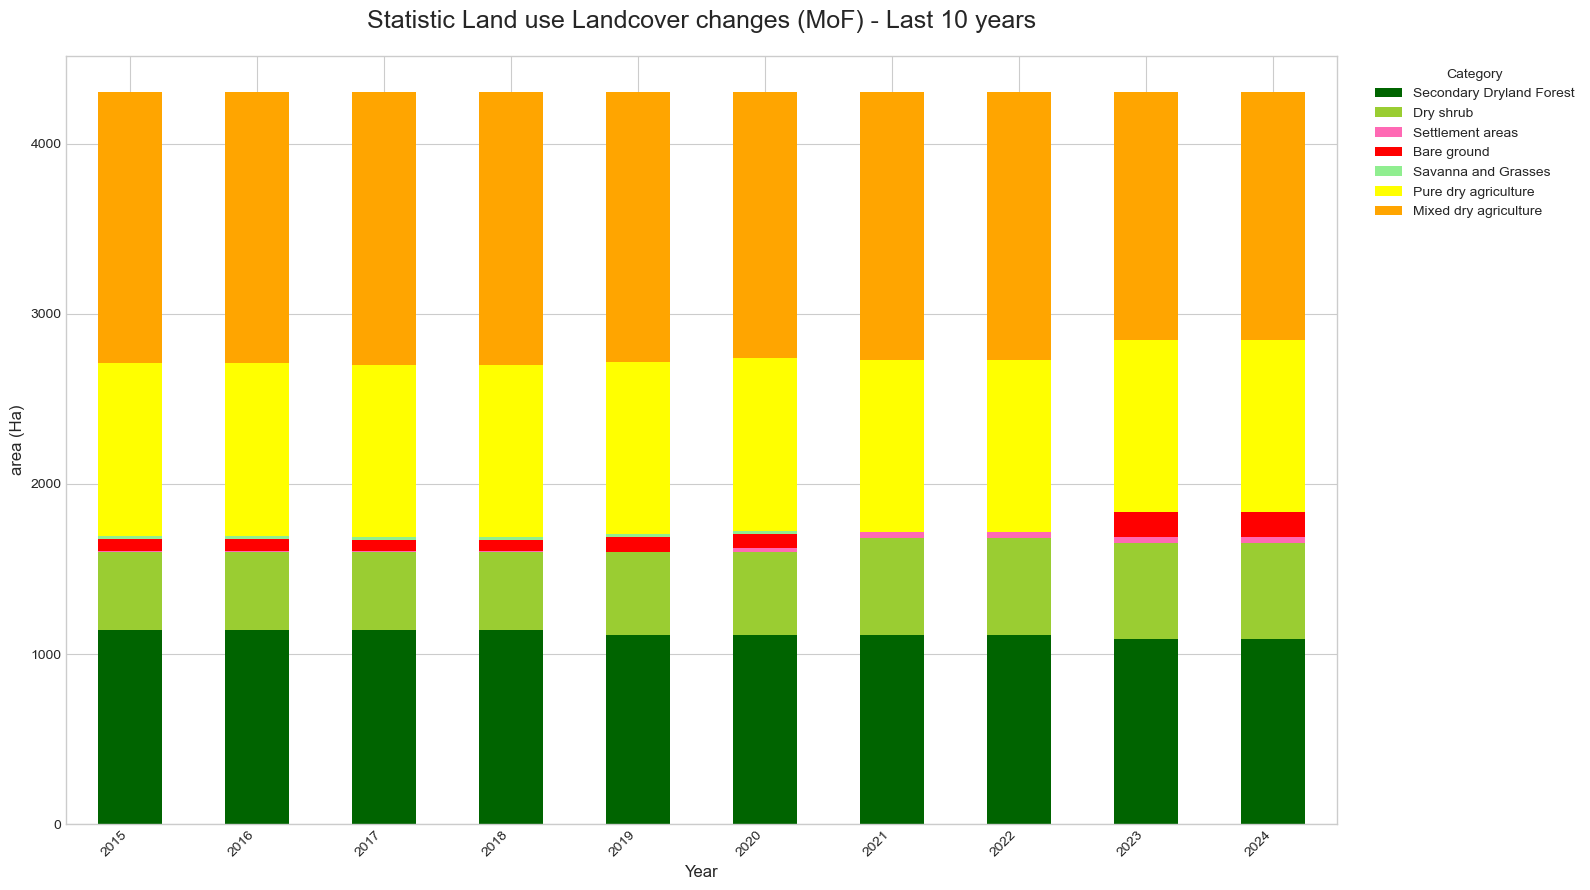

In [102]:
import matplotlib.pyplot as plt

#Transpose the DataFrame so that years become rows (for the x-axis)
# and categories become columns (for the stacks in each bar)
df = lc_10_years
df_transposed = df.T

column_name = [lc_class.rstrip() for lc_class in df_transposed.iloc[1].to_list()]
df_transposed.columns = column_name
df_transposed = df_transposed.iloc[2:]
df_transposed.index.name = "Year"

# Create and customize the plot
# Use a clean plot style
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Define the new color map based on your description
color_map = {
    'Secondary Dryland Forest': '#006400',  # Dark Green
    'Dry shrub': '#9ACD32',               # Green-Yellowish
    'Settlement areas': '#FF69B4',         # Pink
    'Bare ground': '#FF0000',             # Red
    'Savanna and Grasses': '#90EE90',      # Light Green
    'Pure dry agriculture': '#FFFF00',     # Yellow
    'Mixed dry agriculture': '#FFA500'      # Orange
}

# Create the stacked bar chart from the transposed DataFrame
ax = df_transposed.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 9), # Set the figure size for better readability
color=color_map  # Apply the new custom colors
)

# Set titles and labels for clarity
ax.set_title('Statistic Land use Landcover changes (MoF) - Last 10 years', fontsize=18, pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('area (Ha)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust legend to be outside the plot area
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Ensure everything fits without overlapping
plt.tight_layout()

# 4. Show or save the plot
# To display the plot in a script or notebook:
plt.show()

In [105]:
# for i in df_transposed.columns:
#     print(i)

# refer to the FREL data:
frel_data = pd.read_csv(r'C:\Users\q_bal\Documents\arcgis_restapi_notebooks\FREL_DATA - combined_database_for_csv.csv')

print(frel_data['island_coverage'].unique())

# sulawesi for Muna --> forest, but indonesia for other land use
frel_sulawesi = frel_data[frel_data['island_coverage'].isin(

array(['Bali Nusa Tenggara \n ', 'Java ', 'Kalimantan', 'Maluku', 'Papua',
       'Sulawesi', 'Sumatra', 'Indonesia (Average)', 'Bali Nusa Tenggara',
       'Java', 'Bali Nusa Tenggara* \n', ' Java*\r\n', 'Maluku*',
       'Sulawesi*', 'Bali Nusa Tenggara* ', 'Bali Nusa Tenggara*\n',
       ' Java* \n', ' Kalimantan', 'Sulawesi* ', 'Sumatra* ', 'Java*',
       'Sumatra*'], dtype=object)

['Secondary Dryland Forest',
 'Dry shrub',
 'Settlement areas',
 'Bare ground',
 'Savanna and Grasses',
 'Pure dry agriculture',
 'Mixed dry agriculture']